# Ejercicio Práctico 1 — Análisis de Estrategias de Opciones con Datos Reales

Edgardo Gonzalez Tejeda

**Activo:** QQQ 
**Estrategias:** Long Straddle · Bull Call Spread

In [ ]:


import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from datetime import datetime

plt.rcParams.update({'figure.dpi':120,'font.size':10,
                     'axes.spines.top':False,'axes.spines.right':False})
print('Librerias OK')

Librerias OK



## 1. Descarga de la cadena de opciones

In [15]:
ticker = yf.Ticker('QQQ')

# Precio actual
S0 = ticker.fast_info['last_price']
print(f'Precio actual QQQ: ${S0:.2f}')

# Fechas de vencimiento disponibles
exps = ticker.options
print('\nVencimientos disponibles (primeros 6):')
for e in exps[:6]:
    print(' ', e)

Precio actual QQQ: $714.71

Vencimientos disponibles (primeros 6):
  2026-05-14
  2026-05-15
  2026-05-18
  2026-05-19
  2026-05-20
  2026-05-21


In [ ]:
# Elegir vencimiento 30 dias
exp_date = exps[1]   
print(f'Vencimiento seleccionado: {exp_date}')

chain = ticker.option_chain(exp_date)
calls = chain.calls.copy()
puts  = chain.puts.copy()

# Tiempo al vencimiento en años
T = (datetime.strptime(exp_date, '%Y-%m-%d') - datetime.today()).days / 365
r = 0.0425   # tasa libre de riesgo

print(f'T = {T:.4f} anos ({T*365:.0f} dias)')
print(f'Calls disponibles: {len(calls)} | Puts: {len(puts)}')

# Mostrar calls cerca del ATM
atm_idx = (calls['strike'] - S0).abs().idxmin()
print('\nCalls cerca del ATM:')
print(calls.loc[atm_idx-2:atm_idx+4,
      ['strike','lastPrice','bid','ask','impliedVolatility','volume','openInterest']].to_string(index=False))

Vencimiento seleccionado: 2026-05-15
T = 0.0027 anos (1 dias)
Calls disponibles: 262 | Puts: 255

Calls cerca del ATM:
 strike  lastPrice  bid  ask  impliedVolatility  volume  openInterest
  713.0       6.39 5.69 6.71           0.275886  5100.0          2670
  714.0       5.96 5.34 6.00           0.267219  6334.0          1370
  715.0       5.33 5.27 5.37           0.261177 23743.0         10431
  716.0       4.81 4.66 4.94           0.263252  7512.0          2579
  720.0       2.98 2.84 3.20           0.256843 22801.0         17026
  725.0       1.42 1.31 1.53           0.240364 14285.0         13785
  730.0       0.60 0.59 0.62           0.228890  8675.0          6515



## 2. Black-Scholes: precios y griegas

In [17]:
def bs_price(S, K, r, sigma, T, tipo='call'):
    if T <= 0: return max(S-K,0) if tipo=='call' else max(K-S,0)
    d1 = (np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if tipo=='call':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_greeks(S, K, r, sigma, T, tipo='call'):
    d1 = (np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    gamma = norm.pdf(d1)/(S*sigma*np.sqrt(T))
    vega  = S*norm.pdf(d1)*np.sqrt(T)/100
    if tipo=='call':
        delta = norm.cdf(d1)
        theta = (-(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2))/365
    else:
        delta = norm.cdf(d1)-1
        theta = (-(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2))/365
    return {'Delta':delta,'Gamma':gamma,'Theta':theta,'Vega':vega}

print('Funciones BS definidas')

Funciones BS definidas



## 3. Estrategia 1 — Long Straddle
**Construccion:** Compra 1 call ATM + Compra 1 put ATM (mismo strike, mismo vencimiento)

In [ ]:
# Seleccionar strike ATM
K_str = calls.loc[(calls['strike']-S0).abs().idxmin(), 'strike']
print(f'Strike ATM seleccionado: {K_str}')

# Obtener precios de mercado 
c_row = calls[calls['strike']==K_str].iloc[0]
p_row = puts[puts['strike']==K_str].iloc[0]

c_mid = (c_row['bid']+c_row['ask'])/2
p_mid = (p_row['bid']+p_row['ask'])/2
sigma_c = c_row['impliedVolatility']
sigma_p = p_row['impliedVolatility']
sigma_str = (sigma_c+sigma_p)/2

# Primas
str_debit = c_mid + p_mid   # costo total del straddle

print(f'\nCall ATM  K={K_str}: mid=${c_mid:.2f}  IV={sigma_c:.1%}')
print(f'Put  ATM  K={K_str}: mid=${p_mid:.2f}  IV={sigma_p:.1%}')
print(f'Debito neto (costo):  ${str_debit:.2f}')
print(f'Breakeven superior:   ${K_str+str_debit:.2f}')
print(f'Breakeven inferior:   ${K_str-str_debit:.2f}')
print(f'Perdida maxima:       ${str_debit:.2f} (si ST = K al vencimiento)')
print(f'Ganancia maxima:      Ilimitada')

Strike ATM seleccionado: 715.0

Call ATM  K=715.0: mid=$5.32  IV=26.1%
Put  ATM  K=715.0: mid=$4.71  IV=22.1%
Debito neto (costo):  $10.03
Breakeven superior:   $725.02
Breakeven inferior:   $704.98
Perdida maxima:       $10.03 (si ST = K al vencimiento)
Ganancia maxima:      Ilimitada


In [19]:
# Griegas individuales
g_c = bs_greeks(S0, K_str, r, sigma_c, T, 'call')
g_p = bs_greeks(S0, K_str, r, sigma_p, T, 'put')

df_str_greeks = pd.DataFrame({
    'Contrato':       ['Long Call ATM','Long Put ATM','Neto Straddle'],
    'Posicion':       ['+1','+1',''],
    'Prima':          [c_mid, p_mid, str_debit],
    'Delta':          [g_c['Delta'], g_p['Delta'], g_c['Delta']+g_p['Delta']],
    'Gamma':          [g_c['Gamma'], g_p['Gamma'], g_c['Gamma']+g_p['Gamma']],
    'Theta':          [g_c['Theta'], g_p['Theta'], g_c['Theta']+g_p['Theta']],
    'Vega':           [g_c['Vega'],  g_p['Vega'],  g_c['Vega']+g_p['Vega']],
})
print('Griegas — Long Straddle')
print(df_str_greeks.round(5).to_string(index=False))

Griegas — Long Straddle
     Contrato Posicion  Prima    Delta   Gamma    Theta    Vega
Long Call ATM       +1  5.320  0.49429 0.04083 -1.98943 0.14923
 Long Put ATM       +1  4.705 -0.50767 0.04826 -1.60585 0.14922
Neto Straddle          10.025 -0.01338 0.08908 -3.59528 0.29844


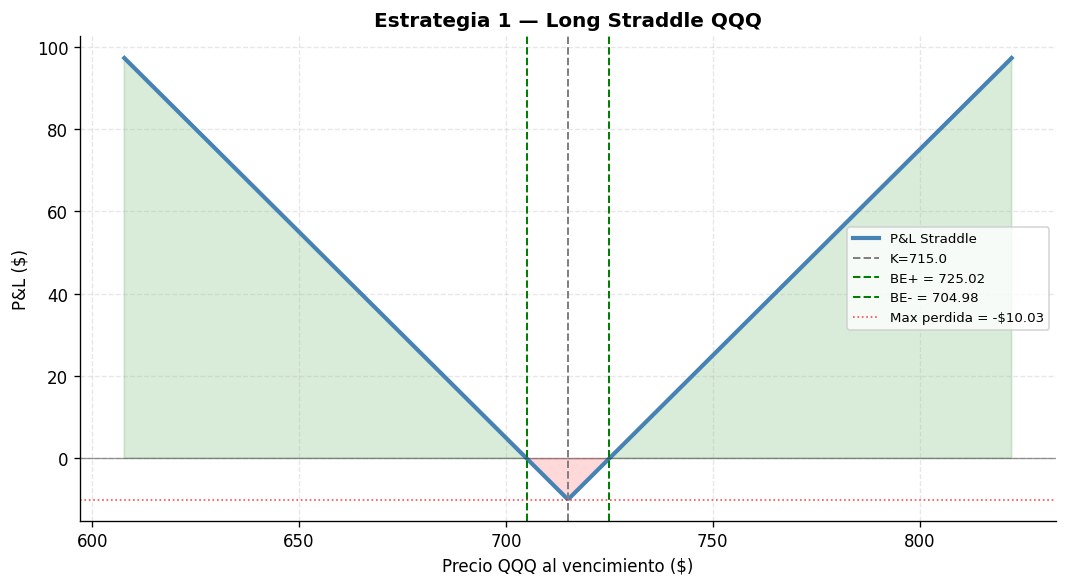

In [21]:
# Diagrama de payoff
ST = np.linspace(K_str*0.85, K_str*1.15, 500)
payoff_str = np.maximum(ST-K_str,0) + np.maximum(K_str-ST,0) - str_debit

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(ST, payoff_str, 'steelblue', lw=2.5, label='P&L Straddle')
ax.fill_between(ST, payoff_str, 0, where=payoff_str>0, alpha=0.15, color='green')
ax.fill_between(ST, payoff_str, 0, where=payoff_str<=0, alpha=0.15, color='red')
ax.axhline(0, color='black', lw=0.8, alpha=0.4)
ax.axvline(K_str,              color='gray',   lw=1.2, ls='--', label=f'K={K_str}')
ax.axvline(K_str+str_debit,    color='green',  lw=1.2, ls='--', label=f'BE+ = {K_str+str_debit:.2f}')
ax.axvline(K_str-str_debit,    color='green',  lw=1.2, ls='--', label=f'BE- = {K_str-str_debit:.2f}')
ax.axhline(-str_debit, color='red', lw=1, ls=':', alpha=0.7, label=f'Max perdida = -${str_debit:.2f}')
ax.set_xlabel('Precio QQQ al vencimiento ($)')
ax.set_ylabel('P&L ($)')
ax.set_title('Estrategia 1 — Long Straddle QQQ', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, ls='--')
plt.tight_layout()
plt.show()

### Análisis — Long Straddle

El Straddle se implementa como una estrategia de dirección neutral cuando se anticipa un movimiento significativo en el precio sin certeza sobre su rumbo, escenario común ante eventos de alta volatilidad realizada como anuncios de la FED o reportes de ganancias. En términos de griegas, la posición mantiene una Vega neta positiva, lo que significa que se beneficia directamente de un incremento en la volatilidad implícita y la incertidumbre; sin embargo, este beneficio se ve contrarrestado por una Theta neta negativa, lo que implica que el paso del tiempo erosiona el valor de la estrategia y obliga a que el movimiento del mercado ocurra de manera acelerada para evitar pérdidas por decaimiento temporal.


## 4. Estrategia 2 — Bull Call Spread
**Construccion:** Compra 1 call ATM + Venta 1 call OTM (mismo vencimiento)

In [ ]:
# Strike OTM 2% por encima del ATM
K1_bcs = K_str
K2_bcs = calls[calls['strike'] > K1_bcs*1.015]['strike'].iloc[0]
print(f'Long Call  K1 = {K1_bcs}')
print(f'Short Call K2 = {K2_bcs}')

c1_row = calls[calls['strike']==K1_bcs].iloc[0]
c2_row = calls[calls['strike']==K2_bcs].iloc[0]

c1_mid = (c1_row['bid']+c1_row['ask'])/2
c2_mid = (c2_row['bid']+c2_row['ask'])/2
sigma1 = c1_row['impliedVolatility']
sigma2 = c2_row['impliedVolatility']

bcs_debit   = c1_mid - c2_mid
bcs_max_pnl = (K2_bcs - K1_bcs) - bcs_debit
bcs_be      = K1_bcs + bcs_debit

print(f'\nLong  Call K1={K1_bcs}: mid=${c1_mid:.2f}  IV={sigma1:.1%}')
print(f'Short Call K2={K2_bcs}: mid=${c2_mid:.2f}  IV={sigma2:.1%}')
print(f'Debito neto:     ${bcs_debit:.2f}')
print(f'Ganancia maxima: ${bcs_max_pnl:.2f}')
print(f'Perdida maxima:  -${bcs_debit:.2f}')
print(f'Breakeven:       ${bcs_be:.2f}')

Long Call  K1 = 715.0
Short Call K2 = 730.0

Long  Call K1=715.0: mid=$5.32  IV=26.1%
Short Call K2=730.0: mid=$0.60  IV=22.9%
Debito neto:     $4.71
Ganancia maxima: $10.29
Perdida maxima:  -$4.71
Breakeven:       $719.72


In [23]:
# Griegas individuales Bull Call Spread
g_c1 = bs_greeks(S0, K1_bcs, r, sigma1, T, 'call')
g_c2 = bs_greeks(S0, K2_bcs, r, sigma2, T, 'call')

# Short en K2 -> griegas negadas
neto = {k: g_c1[k] - g_c2[k] for k in g_c1}

df_bcs_greeks = pd.DataFrame({
    'Contrato':  ['Long Call K1','Short Call K2','Neto Spread'],
    'Posicion':  ['+1','-1',''],
    'Prima':     [c1_mid, -c2_mid, bcs_debit],
    'Delta':     [g_c1['Delta'], -g_c2['Delta'], neto['Delta']],
    'Gamma':     [g_c1['Gamma'], -g_c2['Gamma'], neto['Gamma']],
    'Theta':     [g_c1['Theta'], -g_c2['Theta'], neto['Theta']],
    'Vega':      [g_c1['Vega'],  -g_c2['Vega'],  neto['Vega']],
})
print('Griegas — Bull Call Spread')
print(df_bcs_greeks.round(5).to_string(index=False))

Griegas — Bull Call Spread
     Contrato Posicion  Prima    Delta    Gamma    Theta     Vega
 Long Call K1       +1  5.320  0.49429  0.04083 -1.98943  0.14923
Short Call K2       -1 -0.605 -0.03996 -0.01006  0.37197 -0.03221
  Neto Spread           4.715  0.45432  0.03077 -1.61746  0.11701


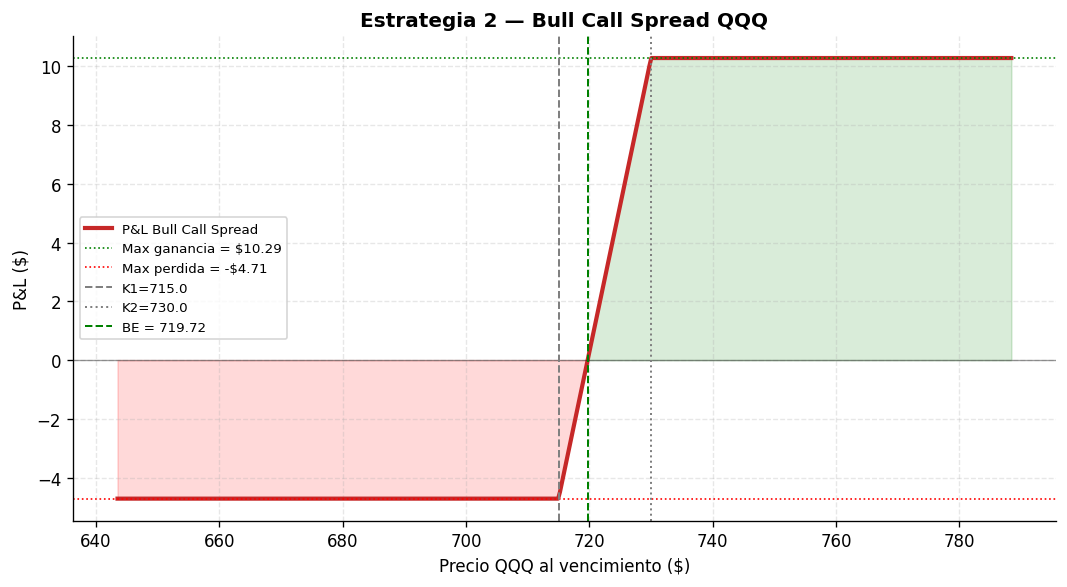

In [24]:
# Diagrama de payoff Bull Call Spread
ST2    = np.linspace(K1_bcs*0.90, K2_bcs*1.08, 500)
payoff_bcs = np.maximum(ST2-K1_bcs,0) - np.maximum(ST2-K2_bcs,0) - bcs_debit

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(ST2, payoff_bcs, '#C62828', lw=2.5, label='P&L Bull Call Spread')
ax.fill_between(ST2, payoff_bcs, 0, where=payoff_bcs>0,  alpha=0.15, color='green')
ax.fill_between(ST2, payoff_bcs, 0, where=payoff_bcs<=0, alpha=0.15, color='red')
ax.axhline(0, color='black', lw=0.8, alpha=0.4)
ax.axhline(bcs_max_pnl, color='green', lw=1, ls=':', label=f'Max ganancia = ${bcs_max_pnl:.2f}')
ax.axhline(-bcs_debit,  color='red',   lw=1, ls=':', label=f'Max perdida = -${bcs_debit:.2f}')
ax.axvline(K1_bcs, color='gray',  lw=1.2, ls='--', label=f'K1={K1_bcs}')
ax.axvline(K2_bcs, color='gray',  lw=1.2, ls=':',  label=f'K2={K2_bcs}')
ax.axvline(bcs_be, color='green', lw=1.2, ls='--', label=f'BE = {bcs_be:.2f}')
ax.set_xlabel('Precio QQQ al vencimiento ($)')
ax.set_ylabel('P&L ($)')
ax.set_title('Estrategia 2 — Bull Call Spread QQQ', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, ls='--')
plt.tight_layout()
plt.show()

### Análisis — Bull Call Spread

El Bull Call Spread se emplea ante la expectativa de un alza moderada y controlada en el precio del activo, buscando que este se desplace hacia el strike corto en un entorno de volatilidad estable o decreciente. Desde la perspectiva de las griegas, la estrategia mantiene una Delta neta positiva que confirma el sesgo alcista, aunque con una magnitud menor a la de una opción simple, lo que limita la ganancia a favor de un menor costo de entrada. Por su parte, la Vega neta negativa (o cercana a cero) permite neutralizar la exposición a cambios bruscos en la volatilidad implícita, protegiendo la posición en escenarios donde la incertidumbre disminuye, a diferencia de las estrategias de volatilidad pura.